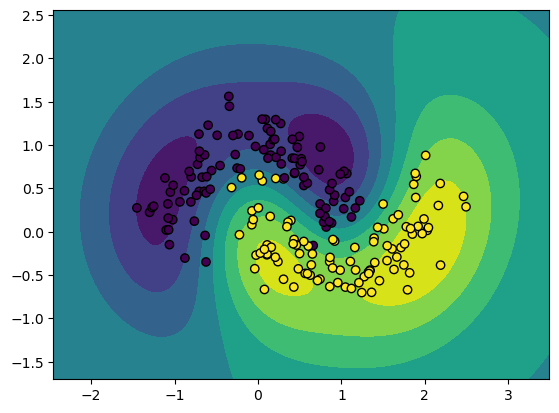

Class weights (λ):  [1. 1.]
Regularization parameter (C): 1.0
Number of support vectors for each class: [25 25]
Indexes of support vectors: [  2   6  10  21  23  28  52  68  72  97  99 102 104 106 110 117 142 144
 149 164 167 183 189 194 197   4  13  15  18  34  35  36  47  58  61  77
  90  91 101 111 122 123 132 152 161 172 175 178 184 199]
Dual coefficients (alphas * y):
 [[-1.         -1.         -0.23683429 -1.         -1.         -1.
  -1.         -1.         -1.         -1.         -1.         -1.
  -1.         -1.         -1.         -1.         -1.         -1.
  -1.         -1.         -1.         -1.         -0.68438191 -1.
  -1.          1.          0.26110802  0.91019098  0.74991721  1.
   1.          1.          1.          1.          1.          1.
   1.          1.          1.          1.          1.          1.
   1.          1.          1.          1.          1.          1.
   1.          1.        ]]
Intercept (bias term): [-0.02120058]


In [11]:
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay

X, Xtrain = make_moons(n_samples=200, noise=0.25)

C = None
clf = SVC() if C is None else SVC(C=C)
clf.fit(X, Xtrain)

disp = DecisionBoundaryDisplay.from_estimator(clf, X)
disp.ax_.scatter(X[:, 0], X[:, 1], c=Xtrain, edgecolors='k')
plt.show()

print("Class weights (λ): ", clf.class_weight_)
print("Regularization parameter (C):", 1.0 if C is None else C)
print("Number of support vectors for each class:", clf.n_support_)
print("Indexes of support vectors:", clf.support_)
print("Dual coefficients (alphas * y):\n", clf.dual_coef_)
print("Intercept (bias term):", clf.intercept_)

              precision    recall  f1-score   support

           0       0.88      0.89      0.88       185
           1       0.89      0.88      0.88       190

    accuracy                           0.88       375
   macro avg       0.88      0.88      0.88       375
weighted avg       0.88      0.88      0.88       375



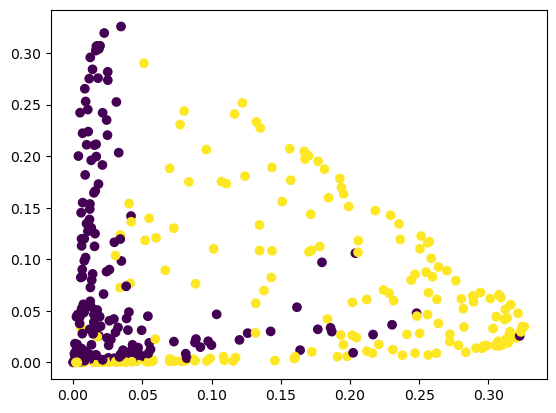

In [12]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

def kernel(Xtest, Xtrain, K):
    """
    Computes the kernel matrix for the given data using vectorized operations.

    Parameters
    ----------
    Xtest : array-like, shape (n_samples_test, n_features)
        Test data.
    Xtrain : array-like, shape (n_samples_train, n_features)
        Training data.
    K : array-like, shape (n_features, n_features)
        Covariance matrix of the training data.
    
    Returns
    -------
    Ktest : array-like, shape (n_samples_test, n_samples_train)
        Kernel matrix between test and training data.
    """
    invK = np.linalg.inv(K)
    diff = Xtest[:, np.newaxis, :] - Xtrain[np.newaxis, :, :]
    # Mahalanobis distance squared
    mdist2 = np.einsum('ijk,kl,ijl->ij', diff, invK, diff)
    norm = 1.0 / np.sqrt((2 * np.pi) ** Xtrain.shape[1] * np.linalg.det(K))
    Ktest = norm * np.exp(-0.5 * mdist2)
    return Ktest

X, y = make_moons(n_samples=750, noise=0.25, random_state=0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

K = np.cov(X_train.T)

K_train = kernel(X_train, X_train, K)
K_test = kernel(X_test, X_train, K) 

clf = SVC(kernel='precomputed').fit(K_train, y_train)
y_pred = clf.predict(K_test)

print(classification_report(y_test, y_pred, target_names=['0', '1']))

Q = K_train

Q0, Q1 = Q[:, 0], Q[:, 1]

plt.scatter(Q0, Q1, c=y_train)
plt.show()

# Param search

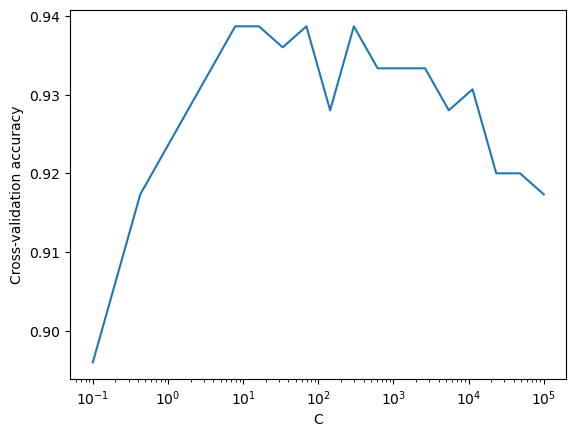

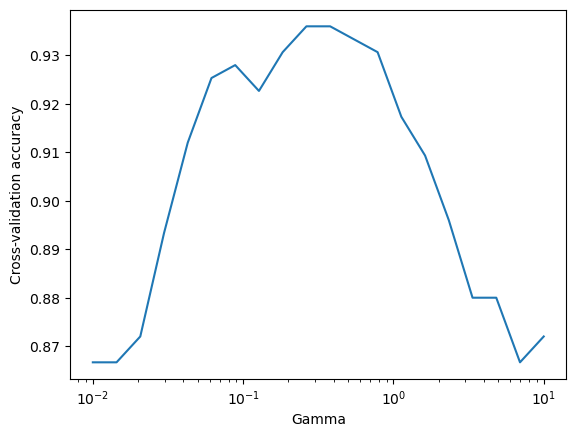

Best parameters found:  {'C': 0.1, 'gamma': 0.46415888336127775}
Best cross-validation score:  0.9413333333333334


In [13]:

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.inspection import DecisionBoundaryDisplay

class CustomKernelSVC(BaseEstimator, ClassifierMixin):
    def __init__(self, C=1.0, gamma=1.0, probability=False):
        self.C = C
        self.gamma = gamma
        self.probability = probability
        self.svc = SVC(kernel='precomputed', C=self.C, probability=self.probability)
        self.X_train_ = None
        self.original_cov_ = None

    def fit(self, X, y):
        self.X_train_ = X
        self.classes_ = np.unique(y)
        self.original_cov_ = np.cov(X.T)
        scaled_cov = self.gamma * self.original_cov_
        K_train = kernel(X, X, scaled_cov)
        self.svc.fit(K_train, y)
        return self

    def predict(self, X):
        scaled_cov = self.gamma * self.original_cov_
        K_test = kernel(X, self.X_train_, scaled_cov)
        return self.svc.predict(K_test)

    def predict_proba(self, X):
        scaled_cov = self.gamma * self.original_cov_
        K_test = kernel(X, self.X_train_, scaled_cov)
        return K_test

Cs = np.logspace(-1, 5, 20)
scores = []
for C in Cs:
    clf = CustomKernelSVC(C=C, gamma=1.0)
    score = cross_val_score(clf, X_train, y_train, cv=5)
    scores.append(score.mean())

plt.semilogx(Cs, scores)
plt.xlabel('C')
plt.ylabel('Cross-validation accuracy')
plt.show()

gammas = np.logspace(-2, 1, 20)
scores = []
for gamma in gammas:
    clf = CustomKernelSVC(C=1.0, gamma=gamma)
    score = cross_val_score(clf, X_train, y_train, cv=5)
    scores.append(score.mean())

plt.semilogx(gammas, scores)
plt.xlabel('Gamma')
plt.ylabel('Cross-validation accuracy')
plt.show()

param_grid = {
    'C': np.logspace(-1, 5, 10),
    'gamma': np.logspace(-2, 1, 10)
}

grid = GridSearchCV(CustomKernelSVC(), param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best parameters found: ", grid.best_params_)
print("Best cross-validation score: ", grid.best_score_)

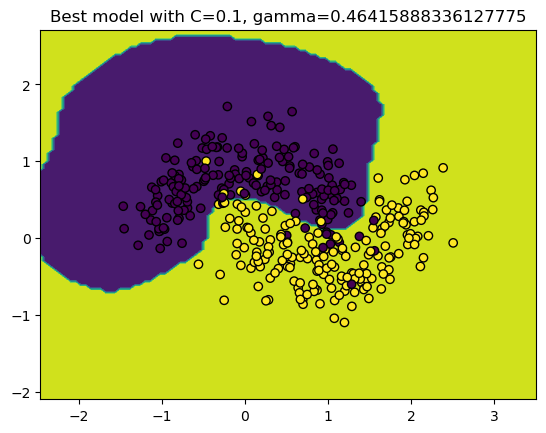

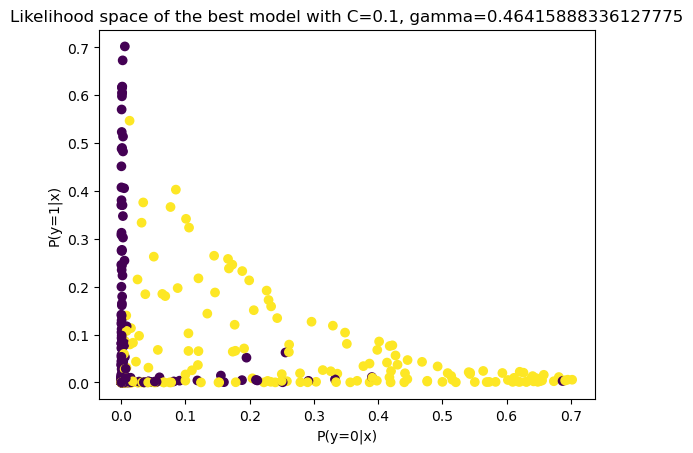

In [14]:
# Plotting the decision boundary of the best model
best_clf = grid.best_estimator_
disp = DecisionBoundaryDisplay.from_estimator(best_clf, X_train, response_method='predict')
disp.ax_.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k')
plt.title(f"Best model with C={grid.best_params_['C']}, gamma={grid.best_params_['gamma']}")
plt.show()

# Plotting the likelihood space of the best model
Q = best_clf.predict_proba(X_train)
Q0, Q1 = Q[:, 0], Q[:, 1]
plt.scatter(Q0, Q1, c=y_train)
plt.xlabel('P(y=0|x)')
plt.ylabel('P(y=1|x)')
plt.title(f"Likelihood space of the best model with C={grid.best_params_['C']}, gamma={grid.best_params_['gamma']}")
plt.show()